In [1]:
# pip install import_ipynb

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

import import_ipynb
from helper import *


## Euler method

In [3]:
def solve_sir_euler(beta, gamma, S0, I0, R0, days, dt):
    # Calculate the total number of discrete time steps
    num_steps = int(days / dt)
    
    # Initialize arrays to store the population values at each time step
    S = np.zeros(num_steps)
    I = np.zeros(num_steps)
    R = np.zeros(num_steps)
    t = np.arange(num_steps) * dt
    
    # Set the initial conditions
    S[0] = S0
    I[0] = I0
    R[0] = R0
    N = S0 + I0 + R0 # Total population size
    
    # Forward Euler iteration loop
    for n in range(num_steps - 1):
        # 1. Calculate the current rates of change (the ODEs)
        dS = - (beta * S[n] * I[n]) / N
        dI = (beta * S[n] * I[n]) / N - (gamma * I[n])
        dR = gamma * I[n]
        
        # 2. Update the next value using the Euler formula: y_{n+1} = y_n + dt * f(t, y)
        S[n+1] = S[n] + dt * dS
        I[n+1] = I[n] + dt * dI
        R[n+1] = R[n] + dt * dR
        
    return t, S, I, R


## Runge-Kutta 4th Order (RK4) Method

While the Forward Euler method provides a straightforward numerical approximation of the SIR model, it relies on a simple linear extrapolation from a single point, which can lead to significant cumulative errors over time. To achieve higher precision without drastically reducing our time step ($dt$), we implement the classical 4th Order Runge-Kutta (RK4) method.

Instead of evaluating the slope only once at the beginning of the time interval, the RK4 algorithm evaluates the derivatives at four distinct points:
1. At the beginning of the interval ($k_1$).
2. At the midpoint of the interval, using an Euler step based on $k_1$ ($k_2$).
3. At the midpoint again, using an Euler step based on $k_2$ ($k_3$).
4. At the end of the interval, using an Euler step based on $k_3$ ($k_4$).

The final value for the next time step is computed using a weighted average of these four slopes, giving the midpoint slopes twice the weight of the endpoints. This complex averaging drastically minimizes the local truncation error to $O(dt^5)$, making RK4 a highly stable and robust solver for modeling the rapid exponential growth phases of an epidemic.

In [4]:
def solve_sir_rk4(beta, gamma, S0, I0, R0, days, dt):
    num_steps = int(days / dt)
    
    # Initialize arrays
    S = np.zeros(num_steps)
    I = np.zeros(num_steps)
    R = np.zeros(num_steps)
    t = np.arange(num_steps) * dt
    
    # Set initial conditions
    S[0], I[0], R[0] = S0, I0, R0
    N = S0 + I0 + R0 
    
    # Define the differential equations as local lambda functions for readability
    dS_dt = lambda S_val, I_val: - (beta * S_val * I_val) / N
    dI_dt = lambda S_val, I_val: (beta * S_val * I_val) / N - (gamma * I_val)
    dR_dt = lambda I_val: gamma * I_val
    
    # RK4 iteration loop
    for n in range(num_steps - 1):
        # 1. Evaluate at the start of the step
        k1_S = dS_dt(S[n], I[n])
        k1_I = dI_dt(S[n], I[n])
        k1_R = dR_dt(I[n])
        
        # 2. Evaluate at the midpoint using k1
        k2_S = dS_dt(S[n] + 0.5 * dt * k1_S, I[n] + 0.5 * dt * k1_I)
        k2_I = dI_dt(S[n] + 0.5 * dt * k1_S, I[n] + 0.5 * dt * k1_I)
        k2_R = dR_dt(I[n] + 0.5 * dt * k1_I)
        
        # 3. Evaluate at the midpoint using k2
        k3_S = dS_dt(S[n] + 0.5 * dt * k2_S, I[n] + 0.5 * dt * k2_I)
        k3_I = dI_dt(S[n] + 0.5 * dt * k2_S, I[n] + 0.5 * dt * k2_I)
        k3_R = dR_dt(I[n] + 0.5 * dt * k2_I)
        
        # 4. Evaluate at the end of the step using k3
        k4_S = dS_dt(S[n] + dt * k3_S, I[n] + dt * k3_I)
        k4_I = dI_dt(S[n] + dt * k3_S, I[n] + dt * k3_I)
        k4_R = dR_dt(I[n] + dt * k3_I)
        
        # Calculate the weighted average to find the next value
        S[n+1] = S[n] + (dt / 6.0) * (k1_S + 2*k2_S + 2*k3_S + k4_S)
        I[n+1] = I[n] + (dt / 6.0) * (k1_I + 2*k2_I + 2*k3_I + k4_I)
        R[n+1] = R[n] + (dt / 6.0) * (k1_R + 2*k2_R + 2*k3_R + k4_R)
        
    return t, S, I, R

## Parameter Sensitivity Analysis

To fully understand the dynamics of the SIR model, it is necessary to examine how variations in the transmission rate ($\beta$) and the recovery rate ($\gamma$) influence the epidemic curve. The fundamental driver of this behavior is the basic reproduction number, defined as $R_0 = \frac{\beta}{\gamma}$. This ratio represents the expected number of secondary infections generated by a single infected individual in a fully susceptible population. 

As demonstrated in the first scenario below (varying $\beta$ while holding $\gamma$ constant), increasing the transmission rate leads to a significantly steeper exponential growth phase and a higher peak of infection. Conversely, artificially lowering $\beta$ simulates public health interventions such as social distancing, resulting in a delayed and much lower peak—a concept commonly referred to as "flattening the curve." 

In the second scenario (varying $\gamma$ while holding $\beta$ constant), the focus shifts to the duration of the infectious period. Increasing the recovery rate simulates the effects of improved medical treatments. A higher $\gamma$ causes individuals to transition into the recovered compartment more quickly, limiting their window to transmit the virus and drastically reducing the epidemic peak.

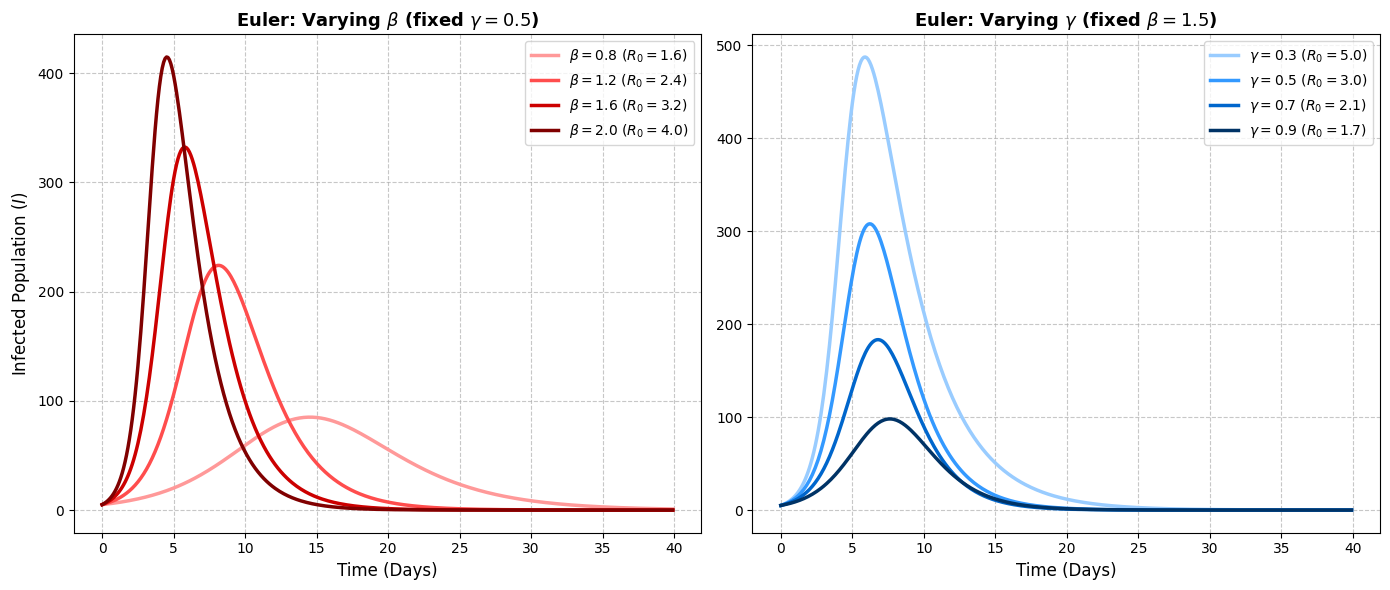

In [5]:
plot_model_sensitivity(
    solver_func=solve_sir_euler, 
    S0=995, I0=5, R0=0, days=40, dt=0.1, 
    betas_to_test=[0.8, 1.2, 1.6, 2.0], fixed_gamma=0.5, 
    gammas_to_test=[0.3, 0.5, 0.7, 0.9], fixed_beta=1.5,
    method_name="Euler"
)
# plot_model_sensitivity(
#     solver_func=solve_sir_rk4, 
#     S0=995, I0=5, R0=0, days=40, dt=0.1, 
#     betas_to_test=[0.8, 1.2, 1.6, 2.0], fixed_gamma=0.5, 
#     gammas_to_test=[0.3, 0.5, 0.7, 0.9], fixed_beta=1.5,
#     method_name="Runge-Kutta 4"
# )

## Data-Driven Parameter Estimation: 1978 influenza outbreak in a British boarding school

While theoretical curves are highly informative, a mathematical model must be grounded in reality. In this section, we apply the SIR model to real-world data: the 1978 influenza outbreak in a British boarding school. 

Instead of guessing the parameters, we use a computational optimization algorithm (`scipy.optimize.curve_fit`) to estimate the specific $\beta$ and $\gamma$ rates that best describe the early stages of this specific virus. To rigorously test our model's forecasting power, we implement a train-test split. We train the algorithm on only the first 7 days of the outbreak, and then run the simulation out to 14 days to see if the mathematics can accurately predict the end of the epidemic that it has not yet "seen."

In [6]:
#Data
file = '../Data/boarding_school_data.csv'
N = 763
train_days = 7
sim_days = 14 
dt = 0.1

### Euler method:

--- Running Pipeline for solve_sir_euler ---
Calculating parameters from data...
Calculated Transmission Rate (Beta): 1.8268
Calculated Recovery Rate (Gamma): 0.4971
Calculated Basic Reproduction Number (R0): 3.67
Running simulation...
Generating plot...



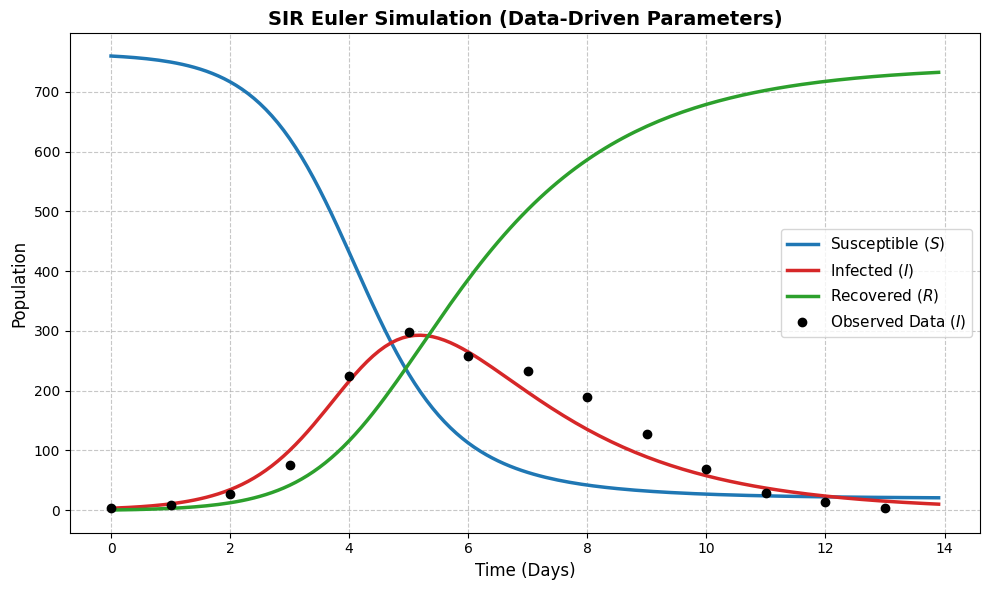

(np.float64(1.8267992619770075), np.float64(0.49713423116053856))

In [7]:
run_and_plot_data_driven_model(
    csv_file=file, 
    total_population=N, 
    days_to_train=train_days, 
    simulation_days=sim_days, 
    time_step=dt, 
    solver_func=solve_sir_euler, 
    plot_title="SIR Euler Simulation (Data-Driven Parameters)"
)

### RK4

--- Running Pipeline for solve_sir_rk4 ---
Calculating parameters from data...
Calculated Transmission Rate (Beta): 1.7389
Calculated Recovery Rate (Gamma): 0.4678
Calculated Basic Reproduction Number (R0): 3.72
Running simulation...
Generating plot...



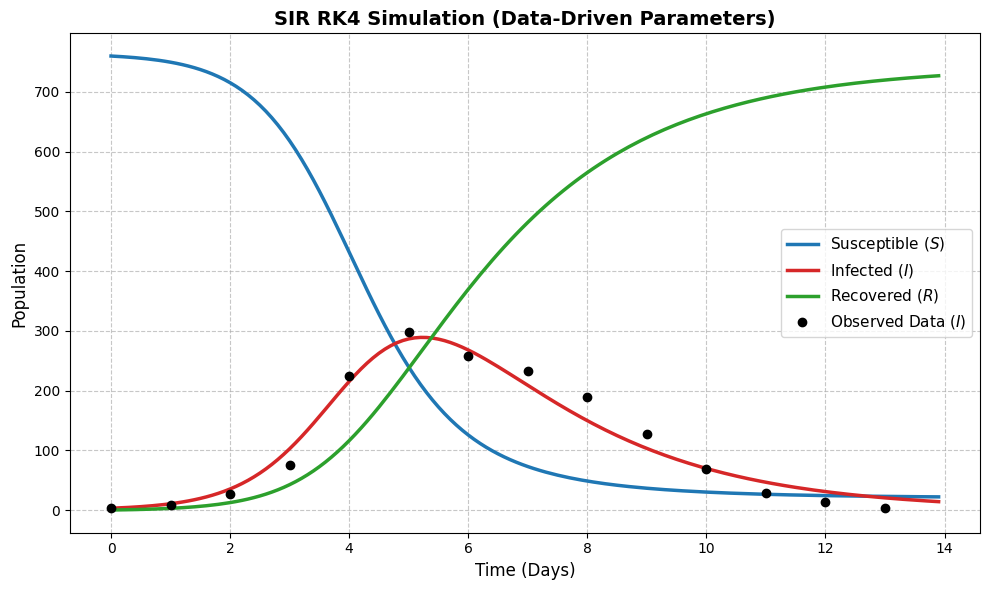

(np.float64(1.7388752790026563), np.float64(0.467818857278441))

In [8]:
run_and_plot_data_driven_model(
        csv_file=file, 
        total_population=N, 
        days_to_train=train_days, 
        simulation_days=sim_days, 
        time_step=dt, 
        solver_func=solve_sir_rk4, 
        plot_title="SIR RK4 Simulation (Data-Driven Parameters)"
    )

t a highly precise time step of $dt = 0.1$, the Euler and RK4 methods look visually identical. But what should we expect from these models if we increase the step size?Because the Euler method is a simple linear approximation, it evaluates the current rate of infection and draws a straight line directly to the next step. It cannot "see" the curve bending in between. RK4, on the other hand, calculates a weighted average of four different slopes. By checking the midpoints of the time interval, it effectively anticipates the curvature of the epidemic. With this mathematical advantage, RK4 provides much better numerical stability. We expect it to remain highly precise even when forced to use much larger time steps, as shown in the example below.

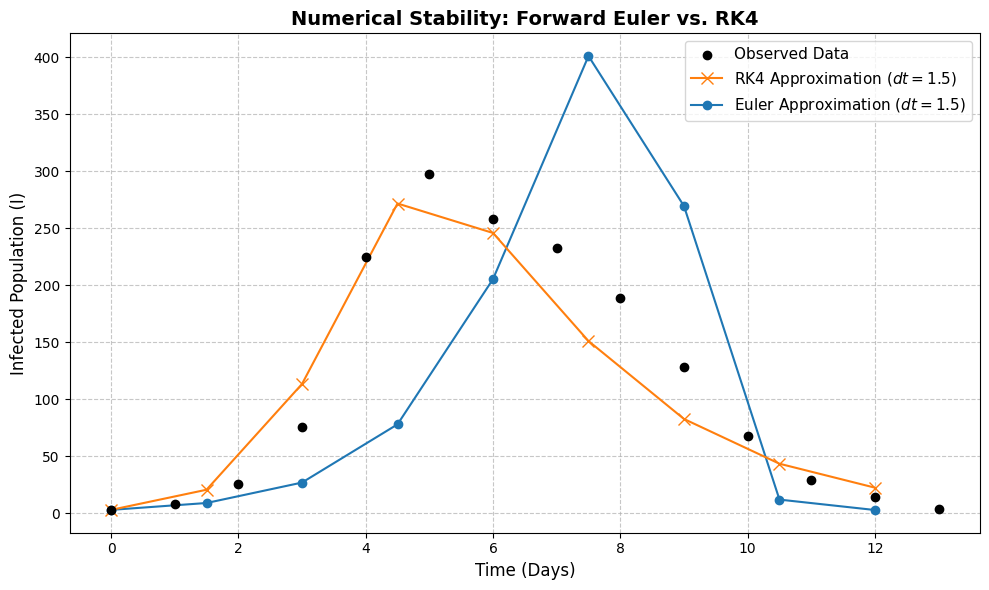

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Get data
df = pd.read_csv(file)
real_days = df['day'].values
real_infected = df['infected'].values

# Lets take some fixed params
calc_beta = 1.8545
calc_gamma = 0.5046
calc_S0 = 760
calc_I0 = 3
calc_R0 = 0
simulation_days = 14

dt_large = 1.5

# simulations for large time step (dt)
t_euler, _, I_euler, _ = solve_sir_euler(calc_beta, calc_gamma, calc_S0, calc_I0, calc_R0, simulation_days, dt_large)
t_rk4, _, I_rk4, _ = solve_sir_rk4(calc_beta, calc_gamma, calc_S0, calc_I0, calc_R0, simulation_days, dt_large)

# Plotting
plt.figure(figsize=(10, 6))

plt.scatter(real_days, real_infected, color='black', zorder=5, label='Observed Data')
plt.plot(t_rk4, I_rk4, label=f'RK4 Approximation ($dt={dt_large}$)', color='#ff7f0e', marker='x', markersize=8, zorder=3)
plt.plot(t_euler, I_euler, label=f'Euler Approximation ($dt={dt_large}$)', color='#1f77b4', marker='o', markersize=6, zorder=2)

plt.title('Numerical Stability: Forward Euler vs. RK4', fontsize=14, fontweight='bold')
plt.xlabel('Time (Days)', fontsize=12)
plt.ylabel('Infected Population (I)', fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

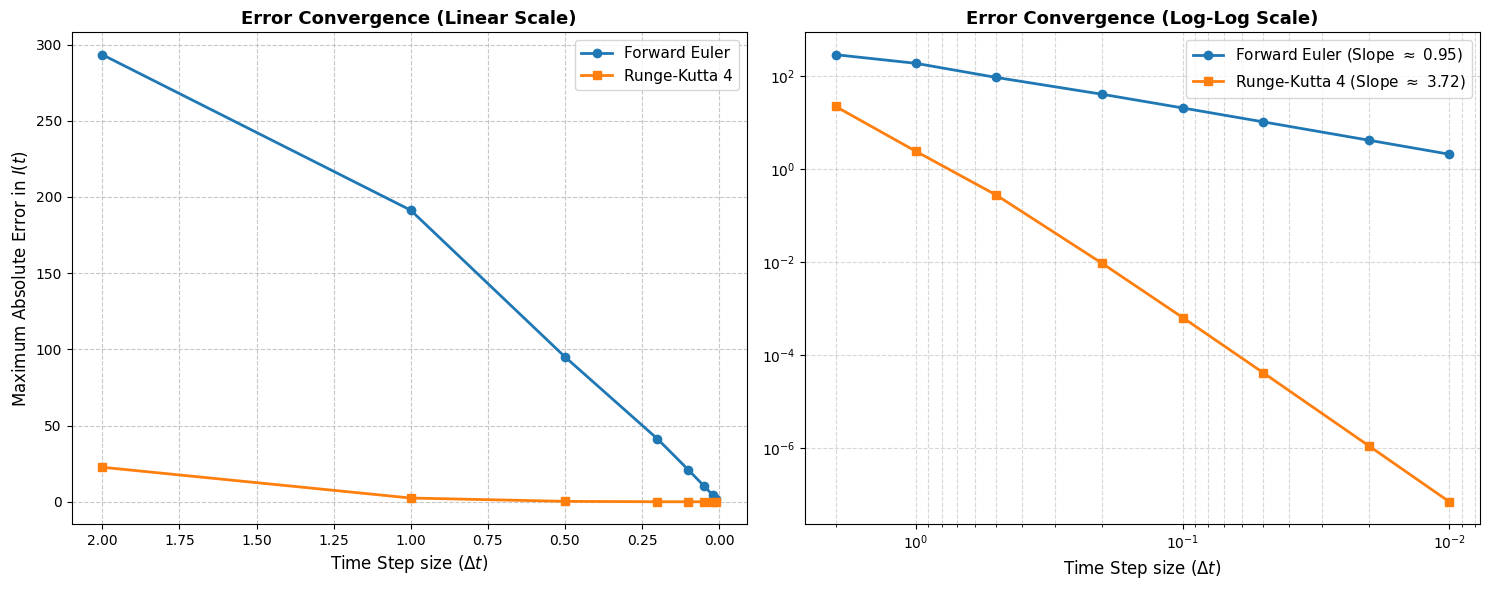

In [10]:
# Execution using the boarding school parameters
calc_beta = 1.8545
calc_gamma = 0.5046

plot_convergence_comparison(
    model1=solve_sir_euler, 
    model2=solve_sir_rk4, 
    name1="Forward Euler", 
    name2="Runge-Kutta 4", 
    S0=760, I0=3, R0=0, 
    beta=calc_beta, gamma=calc_gamma, days=14
)